In [1]:
# 2-Qubit Entanglement & Quantum Kernel Demo
"""
This cell constructs a simple 2-qubit angle-encoding circuit with optional CNOT entanglement,
computes statevectors for a small dataset, builds the quantum kernel K(x,y)=|<φ(x)|φ(y)>|^2,
and compares kernel matrices with and without entanglement.
It also demonstrates a kernel-SVM classification on synthetic labels.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

os.makedirs('outputs', exist_ok=True)

# --- Data: try to load project dataset, else synthetic ---
csv_path = 'docs/power_grid_dataset.csv'
if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    # select two numerical features (fall back if names differ)
    numeric_cols = df.select_dtypes(include=[float,int]).columns.tolist()
    if len(numeric_cols) >= 2:
        X = df[numeric_cols[:2]].values
    else:
        X = df.values[:, :2]
    # form small subset
    X = X[:16].astype(float)
else:
    # synthetic 2D features for demo (16 samples)
    rng = np.random.RandomState(42)
    X = rng.normal(loc=0.0, scale=1.0, size=(16,2))

# normalize to [-pi, pi] for angle encoding
def normalize_angles(X):
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    # avoid div-by-zero
    rng = X_max - X_min
    rng[rng==0] = 1.0
    Xn = (X - X_min) / rng  # [0,1]
    return Xn * 2*np.pi - np.pi

angles = normalize_angles(X)

# --- Quantum circuit builder (statevector via matrix ops) ---
I = np.eye(2, dtype=complex)
Xmat = np.array([[0,1],[1,0]], dtype=complex)
Ymat = np.array([[0,-1j],[1j,0]], dtype=complex)
Zmat = np.array([[1,0],[0,-1]], dtype=complex)
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)

from functools import reduce

def kron(*mats):
    return reduce(np.kron, mats)

# Single-qubit rotation matrices
def Rx(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Xmat

def Ry(theta):
    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*Ymat

# 2-qubit CNOT (control=0,target=1)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

def angle_encode_state(two_angles, entangle=True):
    # two_angles: [a0, a1]
    r0 = Rx(two_angles[0]) @ Ry(two_angles[0])
    r1 = Rx(two_angles[1]) @ Ry(two_angles[1])
    state = kron(r0, r1) @ np.array([1,0,0,0], dtype=complex)  # start |00>
    if entangle:
        state = CNOT @ state
    # normalize numeric errors
    state = state / np.linalg.norm(state)
    return state

# Build statevectors for dataset with and without entanglement
states_ent = np.array([angle_encode_state(a, entangle=True) for a in angles])
states_sep = np.array([angle_encode_state(a, entangle=False) for a in angles])

# Quantum kernel: squared magnitude of inner product
def kernel_matrix(states):
    N = len(states)
    K = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            overlap = np.vdot(states[i], states[j])
            K[i,j] = np.abs(overlap)**2
    return K

K_ent = kernel_matrix(states_ent)
K_sep = kernel_matrix(states_sep)

# Plot kernel heatmaps
plt.figure(figsize=(6,5))
plt.imshow(K_ent, cmap='viridis', vmin=0, vmax=1)
plt.title('Quantum Kernel (entangled)')
plt.colorbar()
plt.tight_layout()
plt.savefig('outputs/qkernel_entangled.png')
plt.close()

plt.figure(figsize=(6,5))
plt.imshow(K_sep, cmap='viridis', vmin=0, vmax=1)
plt.title('Quantum Kernel (separable)')
plt.colorbar()
plt.tight_layout()
plt.savefig('outputs/qkernel_separable.png')
plt.close()

print('Saved kernel heatmaps to outputs/qkernel_entangled.png and outputs/qkernel_separable.png')

# --- Simple classification demo using kernel-SVM with synthetic labels ---
# create binary labels by thresholding first principal component
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
pc = pca.fit_transform(X).ravel()
median = np.median(pc)
y = (pc > median).astype(int)

# Use SVM with precomputed kernel
svc = SVC(kernel='precomputed')
# cross-validate on entangled kernel
scores_ent = cross_val_score(svc, K_ent, y, cv=4)
# and separable kernel
scores_sep = cross_val_score(svc, K_sep, y, cv=4)

# Save a small report
os.makedirs('docs', exist_ok=True)
with open('docs/QKernel_report.txt','w') as f:
    f.write('Quantum kernel classification (4-fold CV)\n')
    f.write(f'Entangled kernel mean accuracy: {scores_ent.mean():.3f} (std {scores_ent.std():.3f})\n')
    f.write(f'Separable kernel mean accuracy: {scores_sep.mean():.3f} (std {scores_sep.std():.3f})\n')

print('Saved docs/QKernel_report.txt')
print('Entangled CV acc:', scores_ent.mean(), 'Separable CV acc:', scores_sep.mean())

Saved kernel heatmaps to outputs/qkernel_entangled.png and outputs/qkernel_separable.png
Saved docs/QKernel_report.txt
Entangled CV acc: 0.5625 Separable CV acc: 0.5625


# Notebook: Quantum Work — Introduction

This notebook demonstrates how to compute "quantum work" using the two-point measurement (TPM) scheme for a small system.

We implement everything with NumPy linear algebra (state vectors, density matrices, Hamiltonians, and projective measurements) so it runs quickly on CPU without external quantum SDKs.

The notebook is commented to explain the mathematical steps and to be used as a clear demonstration for reports or slides.

# Quantum Gates and Matrices (explanatory markdown)
"""
This notebook implements quantum gates directly as NumPy matrices.
Below we show single-qubit Pauli matrices and the Hadamard gate.
"""

Work values: [-1.  0.  1.]
Probabilities: [0.5 0.5 0. ]


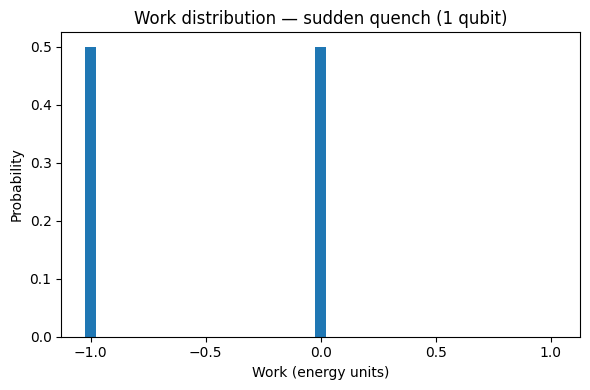

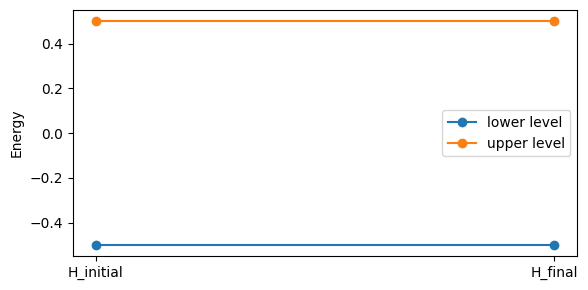

Saved outputs/qwork_work_distribution.png and outputs/qwork_energy_spectrum.png


In [2]:
# Run Simulation: Quantum Work via Two-Point Measurement (TPM) scheme
"""
This cell performs a small quantum work simulation using NumPy linear algebra (no external quantum SDK required).
We implement:
- State vectors and density matrices
- Basic gates (Pauli, Hadamard, CNOT)
- Hamiltonian construction and eigen-decomposition
- Two-point measurement work distribution for a sudden quench protocol
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

os.makedirs('outputs', exist_ok=True)

# --- Helper functions: states and density matrices ---
def ket0():
    return np.array([1.0, 0.0], dtype=complex)

def ket1():
    return np.array([0.0, 1.0], dtype=complex)

def density_from_state(psi):
    """Return density matrix for pure state |psi><psi|."""
    psi = psi.reshape(-1,1)
    return psi @ psi.conj().T

# --- Gates (single-qubit) ---
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
H = (1/np.sqrt(2)) * np.array([[1,1],[1,-1]], dtype=complex)

# Build multi-qubit operators via tensor product
from functools import reduce

def kron(*mats):
    return reduce(np.kron, mats)

# 2-qubit CNOT (control qubit 0, target qubit 1)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

# --- Hamiltonians ---
# Example: 1-qubit Hamiltonian H = 0.5 * Z (energy levels +/-0.5)
H_initial = 0.5 * Z
# Quenched Hamiltonian: rotate axis to X
H_final = 0.5 * X

# Function: compute TPM work distribution for pure initial state psi
def two_point_work_distribution(psi, H0, H1, U=None, beta=None):
    """Compute work distribution for initial pure state |psi>.
    If U is None (sudden quench), we use projectors onto H0 eigenstates followed by instantaneous change to H1.
    Returns arrays of work values and probabilities.
    If beta provided, psi is treated as thermal sampling (not used here).
    """
    # Diagonalize H0 and H1
    e0, v0 = eigh(H0)
    e1, v1 = eigh(H1)

    # Project initial state onto H0 eigenbasis: probabilities p(n) = |<e0_n|psi>|^2
    p_n = np.abs(v0.conj().T @ psi)**2

    # For sudden quench, state after measurement collapses to |e0_n>, then evolves with U (if provided)
    # If U is None, evolution is identity (instantaneous quench then projective measurement of H1)
    if U is None:
        # transition probabilities to H1 eigenstates: |<e1_m|e0_n>|^2
        trans = np.abs(v1.conj().T @ v0)**2
    else:
        # evolve each |e0_n> by U then transition amplitudes
        trans = np.zeros((len(e1), len(e0)))
        for n in range(len(e0)):
            evolved = U @ v0[:,n]
            trans[:,n] = np.abs(v1.conj().T @ evolved)**2

    # Work values w_{m,n} = e1_m - e0_n with probability p_n * trans[m,n]
    w_vals = []
    w_probs = []
    for n in range(len(e0)):
        for m in range(len(e1)):
            w = e1[m] - e0[n]
            prob = p_n[n] * trans[m,n]
            w_vals.append(w)
            w_probs.append(prob)
    # Aggregate identical work values
    from collections import defaultdict
    agg = defaultdict(float)
    for w,p in zip(w_vals, w_probs):
        agg[np.round(w, 10)] += p
    ws = np.array(sorted(agg.keys()))
    ps = np.array([agg[w] for w in ws])
    return ws, ps

# --- Run demo for a 1-qubit pure-state example ---
# initial state: ground state of H_initial (i.e., |0>)
psi0 = ket0()

ws, ps = two_point_work_distribution(psi0, H_initial, H_final, U=None)

print('Work values:', ws)
print('Probabilities:', ps)

# Plot work distribution
plt.figure(figsize=(6,4))
plt.bar(ws, ps, width=0.05)
plt.xlabel('Work (energy units)')
plt.ylabel('Probability')
plt.title('Work distribution — sudden quench (1 qubit)')
plt.tight_layout()
plt.savefig('outputs/qwork_work_distribution.png')
plt.show()

# Energy spectra
e0, _ = eigh(H_initial)
e1, _ = eigh(H_final)
plt.figure(figsize=(6,3))
plt.plot([0,1],[e0[0],e1[0]],'o-',label='lower level')
plt.plot([0,1],[e0[1],e1[1]],'o-',label='upper level')
plt.xticks([0,1], ['H_initial','H_final'])
plt.ylabel('Energy')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/qwork_energy_spectrum.png')
plt.show()

print('Saved outputs/qwork_work_distribution.png and outputs/qwork_energy_spectrum.png')

In [3]:
# Visualizations: Save plots
# This cell will be populated by the simulation cell and used to save figures if they exist.
import matplotlib.pyplot as plt
plt.style.use('ggplot')
print('Visualization helper ready')

Visualization helper ready


In [4]:
# Quantum Work Demo — Execution Summary Save
# This final cell writes a short execution summary to docs/EXECUTION_SUMMARY.md
import os
os.makedirs('docs', exist_ok=True)
summary = """
Quantum work demo executed from notebooks/QGCN_quantum_demo.ipynb
Generated outputs:
- outputs/qwork_work_distribution.png
- outputs/qwork_energy_spectrum.png
"""
with open('docs/EXECUTION_SUMMARY.md','w') as f:
    f.write(summary)
print('Execution summary saved to docs/EXECUTION_SUMMARY.md')

Execution summary saved to docs/EXECUTION_SUMMARY.md
